# Introduction
Images were sourced through manual verification of urls using:  
- https://www.kaggle.com/code/morescope/ur-human-label-sourcing/
- https://public.tableau.com/app/profile/paul.moresco/viz/reviewspecies/resultdf


Several of our classes have very few examples - so it's expected this won't work super well on those.
There are also several small birds that should probably be grouped - all the attempts at labeling sparrows.

In [1]:
# Data Handling
import pandas as pd

# IO - getting files and images
import requests
import json
import os
import urllib.parse

# For randomizing which images get downloaded
import random
from tqdm.auto import tqdm

# For model loading and fine tuning
from fastai.vision.all import *
from fastai.vision.widgets import *
import torch

print("==== Loaded Libraries ====")

==== Loaded Libraries ====


# Accessing observations (image labels) from the curated list

In [2]:
df = pd.read_csv('/kaggle/input/ur-source-image-urls/result df_data.csv')
df.head()

,scientificName (group),publicURL (copy)
0,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2898.JPG
1,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2882.JPG
2,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2872.JPG
3,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2846.JPG
4,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2782.JPG


In [3]:
# rename fields to consistent for this notebook
df = df.rename(columns={
    'scientificName (group)': 'scientificName',
    'publicURL (copy)': 'publicURL'
})

## Run without minimums to see if probability collapses - validation minimum should be minimum 1

In [4]:
# Adjust as the project progresses:
n_obs_minimum = 26

In [5]:
# Show the results
with pd.option_context('display.width', 0, 'display.max_colwidth', None):
    display(df.head())
    
print(f'Total rows: {len(df)}\n')
print(df['scientificName'].value_counts())

,scientificName,publicURL
0,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2898.JPG
1,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2882.JPG
2,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2872.JPG
3,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2846.JPG
4,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2782.JPG


Total rows: 614

scientificName
Larus delawarensis & Larus smithsonianus         54
Sturnus vulgaris                                 42
Procyon lotor                                    37
Castor canadensis                                37
Turdus migratorius                               36
Sylvilagus floridanus                            34
Canis familiaris                                 33
Ardea herodias                                   32
Actitis macularius                               30
blank                                            30
Anas platyrhynchos                               27
Rattus norvegicus                                26
Nycticorax nycticorax                            25
Passer domesticus                                25
Branta canadensis                                24
Apalone spinifera & Trachemys scripta elegans    22
Canis latrans                                    18
Felis catus                                      17
Didelphis virginiana            

### We're left with 610 rows for 27 classifications 
includes dogs and blanks - we previously only did 10 classifications with min images = 26

In [6]:
# Reduce bird classes
def classify_visual_group(name):
    if name in ["Passer domesticus", "Zonotrichia albicollis"]:
        return "Small Brown Grey Songbirds"
    # elif name in ["Cardinalis cardinalis", "Agelaius phoeniceus"]:
    #     return "Colorful Songbirds"
    # elif name == "Turdus migratorius":
    #     return "Thrushlike"
    # elif name in ["Actitis macularius", "Butorides virescens"]:
    #     return "Small Wading Shorebirds"
    elif name in ["Cardinalis cardinalis", "Agelaius phoeniceus", "Turdus migratorius", "Actitis macularius", "Butorides virescens"]:
        return "Colorful Songbirds Shorbirds Thrushlike"
    elif name in ["Sturnus vulgaris", "Quiscalus quiscula"]:
        return "Iridescent Blackbirds"
    elif name in ["Larus delawarensis & Larus smithsonianus"]:
        return "Gulls"
    elif name in ["Apalone spinifera & Trachemys scripta elegans", "Chelydra serpentina"]:
        return "Tortises"
    else:
        return name

df['scientificName_group'] = df['scientificName'].apply(classify_visual_group)

# drop rows from df where the count by scientificname is <10
counts = df['scientificName'].value_counts()
keep_species = counts[counts >= 10].index

df_filtered = df[df['scientificName'].isin(keep_species)]


print(df_filtered['scientificName_group'].value_counts())

scientificName_group
Colorful Songbirds Shorbirds Thrushlike    77
Gulls                                      54
Iridescent Blackbirds                      42
Castor canadensis                          37
Procyon lotor                              37
Sylvilagus floridanus                      34
Canis familiaris                           33
Ardea herodias                             32
blank                                      30
Anas platyrhynchos                         27
Rattus norvegicus                          26
Nycticorax nycticorax                      25
Small Brown Grey Songbirds                 25
Branta canadensis                          24
Tortises                                   22
Canis latrans                              18
Felis catus                                17
Didelphis virginiana                       12
Name: count, dtype: int64


After condensing categories - we're a little over-represented but that's maybe ok.  
Now there are 20 classes instead of 27 and the classes do provide some filtering for images.

# Downloading Images that meet the criteria
Passing our filtered df to the s3 bucket to request images in grouped train or test splits

In [7]:
# Create the directories
base_dir = '/kaggle/working/images'
test_dir = '/kaggle/working/_tests'
os.makedirs(test_dir, exist_ok=True)

grouped = list(df_filtered.groupby('scientificName_group'))

In [8]:
# Show the structure of the grouped list for understanding
print("speciesName: ", grouped[0][0])
print("dataframe: ")
grouped[0][1].head()

speciesName:  Anas platyrhynchos
dataframe: 


,scientificName,publicURL,scientificName_group
38,Anas platyrhynchos,https://urbanriverrangers.s3.amazonaws.com/images/2025/2025-03-10_UR011/DCIM/100MEDIA/SYFW1220.JPG,Anas platyrhynchos
39,Anas platyrhynchos,https://urbanriverrangers.s3.amazonaws.com/images/2025/2025-03-10_UR005/DCIM/100DSCIM/PICT5597.JPG,Anas platyrhynchos
40,Anas platyrhynchos,https://urbanriverrangers.s3.amazonaws.com/images/2025/2025-03-03_UR032/DCIM/100MEDIA/SYFW0128.JPG,Anas platyrhynchos
41,Anas platyrhynchos,https://urbanriverrangers.s3.amazonaws.com/images/2025/2025-01-28_UR023/DCIM/100MEDIA/SYFW09755.jpg,Anas platyrhynchos
42,Anas platyrhynchos,https://urbanriverrangers.s3.amazonaws.com/images/2025/2025-01-27_UR022/DCIM/100MEDIA/SYFW06786.jpg,Anas platyrhynchos


## Grouped is a list where each index species has a dataframe  so key, value is scientific_name, df of images

/kaggle/working/images/Anas_platyrhynchos/2025-03-10_ur011_syfw1220.jpg


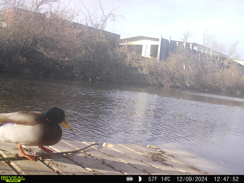

In [9]:
# fast ai version of image downloading
from fastdownload import download_url

ims = grouped[0][1]['publicURL'].tolist()
imn = [f"{url.split('/')[-4].lower()}_{url.split('/')[-1].rsplit('.', 1)[0].lower()}" for url in ims]
imn = [name.removesuffix('.JPG').removesuffix('.jpg') for name in imn] # standardize imn

len(ims)

# Might cause some renaming issues if 
dest = os.path.join(base_dir, grouped[0][0].replace(' ','_'), f'{imn[0]}.jpg')
print(dest)

download_url(ims[0], dest)

im = Image.open(dest)
im.to_thumb(244,244)

Clearly some issues with single species including multiple species - we've seen this before and it will require some cleaning.

In [10]:
# For cleanup while testing
!rm /kaggle/working/images/* -rf

In [11]:
%%time
# fast ai version of all images downloading - drops the mediaID from the pipeline which might be ok
for species, group in grouped:
    group = group.dropna(subset=['publicURL'])

    n_split = len(group) - 1
    train_samples = group.iloc[:n_split]
    test_sample = group.iloc[n_split]

    train_urls = train_samples['publicURL'].tolist()
    test_url = test_sample['publicURL']
    
    
    species_folder = species.replace(' ', '_')
    species_dir = os.path.join(base_dir, species_folder)
    
    download_images(species_dir, urls=train_urls)
    print(species_dir)
    
    # Download test image
    test_image_path = os.path.join(test_dir, f'{species_folder}.JPG')
    download_url(test_url, test_image_path)

print("==== Downloaded Images ====")
    

/kaggle/working/images/Anas_platyrhynchos


/kaggle/working/images/Ardea_herodias


/kaggle/working/images/Branta_canadensis


/kaggle/working/images/Canis_familiaris


/kaggle/working/images/Canis_latrans


...

/kaggle/working/images/Small_Brown_Grey_Songbirds


/kaggle/working/images/Sylvilagus_floridanus


/kaggle/working/images/Tortises


/kaggle/working/images/blank


==== Downloaded Images ====
CPU times: user 6.27 s, sys: 4.44 s, total: 10.7 s
Wall time: 42.6 s


In [12]:
# validate images
fns = get_image_files(base_dir)
failed = verify_images(fns)
print(failed)
failed.map(Path.unlink);

[]


# For each image downloaded we are going to interact with fastai
Dataloaders (dls) are tensors that fastai simplifies for use in model fine-tuning.  
The library loads only what's needed (even though we passed * at the top) and has some built in common features.  

We're planning on using resnet18 - so we want to resize to 224x224 - and want to use aug_transforms() to get some visual variation in images from cameratraps.  
This means that at each pass of the dls to the fine tuning system the model will see slightly different images so it learns how to detect with some variation.

==== Loading images into tensors ====

CPU times: user 11.1 s, sys: 7.24 s, total: 18.3 s
Wall time: 18.8 s


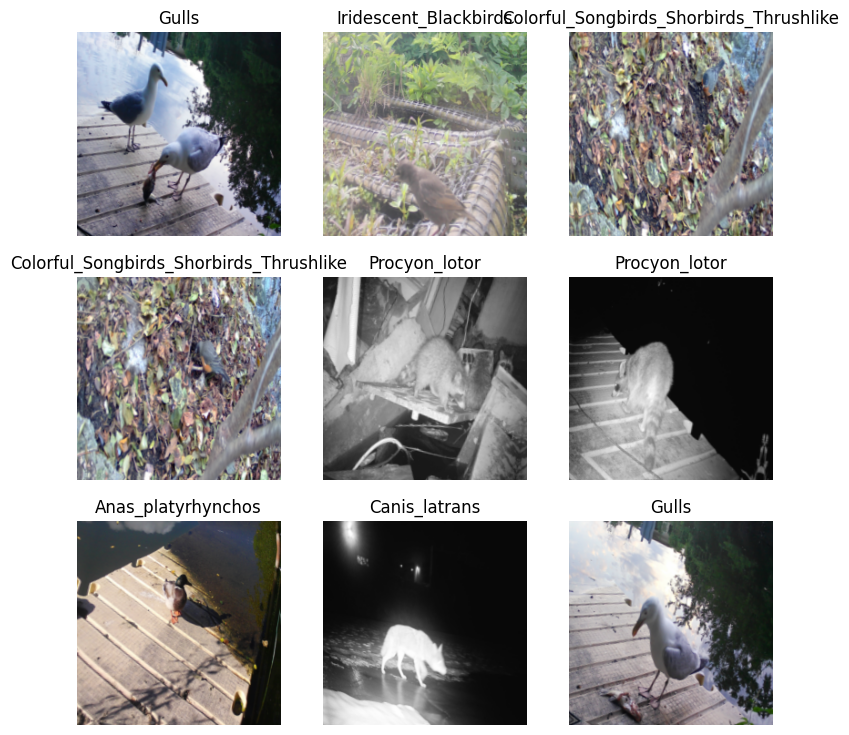

In [13]:
%%time
print('==== Loading images into tensors ====\n')
from sklearn.model_selection import train_test_split

path = Path('/kaggle/working/images')

# Stratified split to balance classes in train/valid sets
def stratified_splitter(items):
    labels = [parent_label(i) for i in items]
    train_idx, valid_idx = train_test_split(
        range(len(items)),
        test_size=0.2,
        stratify=labels,
        random_state=42
    )
    return train_idx, valid_idx

# Custom image trimming class
class CropTopBottom(Transform):
    def __init__(self, top_pct=0.1, bottom_pct=0.1):
        self.top_pct = top_pct
        self.bottom_pct = bottom_pct

    def encodes(self, img: PILImage):
        w, h = img.size
        top = int(h * self.top_pct)
        bottom = int(h * (1 - self.bottom_pct))
        return img.crop((0, top, w, bottom))

# DataBlock with custom splitter - removed batch transforms because the center zoom was cropping animals
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=stratified_splitter,
    item_tfms=[CropTopBottom(top_pct=0.1, bottom_pct=0.1), Resize(224, method='squish')],
    batch_tfms=aug_transforms()
)

# Build DataLoaders
dls = dblock.dataloaders(path)

# Show sample batch
dls.show_batch(max_n=9)

Now when resizing we aren't cutting off animals not centered and aren't introducing new zero padded areas.

# Fine tuning pre-trained models to our classifications
Initially we downloaded the resnet 18 model and fine tuned with 5 epochs to our dataset.  
Images , tests, and data are organized in folders and loaded into dls as appropriate.  

# Seeing what models are best
https://www.kaggle.com/code/morescope/which-image-models-are-best/

In [14]:
import timm

timm.list_models('convnext*')

['convnext_atto',
 'convnext_atto_ols',
 'convnext_atto_rms',
 'convnext_base',
 'convnext_femto',
 'convnext_femto_ols',
 'convnext_large',
 'convnext_large_mlp',
 'convnext_nano',
 'convnext_nano_ols',
 'convnext_pico',
 'convnext_pico_ols',
 'convnext_small',
 'convnext_tiny',
 'convnext_tiny_hnf',
 'convnext_xlarge',
 'convnext_xxlarge',
 'convnext_zepto_rms',
 'convnext_zepto_rms_ols',
 'convnextv2_atto',
 'convnextv2_base',
 'convnextv2_femto',
 'convnextv2_huge',
 'convnextv2_large',
 'convnextv2_nano',
 'convnextv2_pico',
 'convnextv2_small',
 'convnextv2_tiny']

In [15]:
%%time
learn = vision_learner(dls, 'convnext_tiny', metrics=error_rate)

if torch.cuda.is_available():
    learn.model = learn.model.cuda()
    print("Using:", next(learn.model.parameters()).device)  # should print 'cuda:0'
else:
    learn.model = learn.model.cpu()
    print("Using CPU")

# For this version we've seen trying 15 epochs is good 
learn.fine_tune(15)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Using: cuda:0


epoch,train_loss,valid_loss,error_rate,time
0,3.918817,2.213943,0.648649,01:08


epoch,train_loss,valid_loss,error_rate,time
0,1.934402,1.627496,0.441441,01:10
1,1.735709,1.273356,0.342342,01:07
2,1.512464,0.961818,0.279279,01:07
3,1.293525,0.861241,0.270270,01:06
4,1.104873,0.813045,0.252252,01:10
5,0.948351,0.801170,0.225225,01:09
6,0.827920,0.835771,0.252252,01:11
7,0.724053,0.857245,0.261261,01:06
8,0.642274,0.829872,0.234234,01:08
9,0.576637,0.812280,0.234234,01:08


CPU times: user 1min 26s, sys: 58.3 s, total: 2min 24s
Wall time: 18min 18s


Originally We went from 78 to 92% accuracy switching from resnet18 to convnext_tiny
When allowing images with very few examples - we result in a much lower accuracy of 74% - after condensing bird classes that improved to 84%

## Confusion Matrix

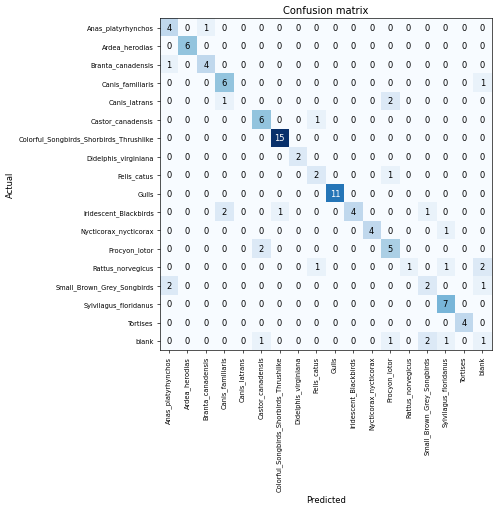

In [16]:
interp = ClassificationInterpretation.from_learner(learn)

# Set figure size large enough for 20 classes
interp.plot_confusion_matrix(figsize=(9, 9), dpi=60)

# Optional: Increase font size for axis labels
import matplotlib.pyplot as plt
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8)
plt.show()

In [17]:
cm = interp.confusion_matrix()
total = cm.sum()
correct = np.trace(cm)  # sum of diagonal
incorrect = total - correct
error_rate = incorrect / total

print(f"Error rate: {error_rate:.4f} ({incorrect}/{total})")

Error rate: 0.2432 (27/111)


Considerably better error rates on our dog, duck, and sandpiper categories
But now blanks are not being labeled well.  

This is ok - we're alright with a high false positive rate (meaning it's actually blank, but there might be an animal worth looking for?)

## Testing a single image prediction
Here we'll look at our test for a beaver and see if the model can predict it correctly.

<Axes: title={'center': 'Probably: Castor_canadensis (0.97)'}>

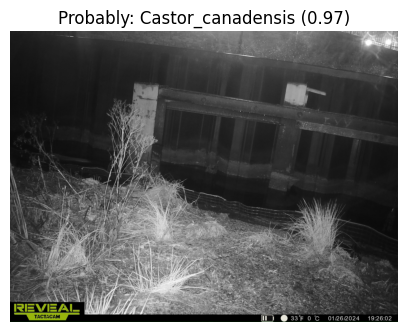

In [18]:
image_path = '/kaggle/working/_tests/Castor_canadensis.JPG'
pred, pred_idx, probs = learn.predict(PILImage.create(image_path))


PILImage.create(image_path).show(title=f"Probably: {pred} ({probs[pred_idx]:.2f})")

## Tabular predictions for all images in the folder

In [19]:
# Predicting in a table for each image
test_path = Path("/kaggle/working/_tests")
test_files = get_image_files(test_path)

results = []
for f in test_files:
    pred_class, pred_idx, pred_probs = learn.predict(f)
    results.append({
        'file': f.name,
        'pred_class': str(pred_class),
        'probability': float(pred_probs[pred_idx]),
        'top3': [
            (learn.dls.vocab[i], format(float(pred_probs[i]), ".4f"))
            for i in pred_probs.argsort(descending=True)[:3]
        ]
    })

results_df = pd.DataFrame(results)
display(results_df)

,file,pred_class,probability,top3
0,blank.JPG,blank,0.976286,"[(blank, 0.9763), (Tortises, 0.0052), (Colorful_Songbirds_Shorbirds_Thrushlike, 0.0048)]"
1,Sylvilagus_floridanus.JPG,Sylvilagus_floridanus,0.648125,"[(Sylvilagus_floridanus, 0.6481), (Castor_canadensis, 0.1810), (Rattus_norvegicus, 0.1028)]"
2,Small_Brown_Grey_Songbirds.JPG,Small_Brown_Grey_Songbirds,0.917524,"[(Small_Brown_Grey_Songbirds, 0.9175), (Castor_canadensis, 0.0551), (Colorful_Songbirds_Shorbirds_Thrushlike, 0.0071)]"
3,Colorful_Songbirds_Shorbirds_Thrushlike.JPG,Colorful_Songbirds_Shorbirds_Thrushlike,0.991626,"[(Colorful_Songbirds_Shorbirds_Thrushlike, 0.9916), (Small_Brown_Grey_Songbirds, 0.0071), (Iridescent_Blackbirds, 0.0008)]"
4,Didelphis_virginiana.JPG,Didelphis_virginiana,0.805689,"[(Didelphis_virginiana, 0.8057), (Rattus_norvegicus, 0.1260), (Procyon_lotor, 0.0629)]"
5,Branta_canadensis.JPG,Branta_canadensis,0.997908,"[(Branta_canadensis, 0.9979), (Anas_platyrhynchos, 0.0016), (blank, 0.0001)]"
6,Felis_catus.JPG,Felis_catus,0.979997,"[(Felis_catus, 0.9800), (Procyon_lotor, 0.0042), (Colorful_Songbirds_Shorbirds_Thrushlike, 0.0038)]"
7,Gulls.JPG,Gulls,0.998059,"[(Gulls, 0.9981), (Canis_latrans, 0.0006), (Canis_familiaris, 0.0005)]"
8,Ardea_herodias.JPG,Ardea_herodias,0.999402,"[(Ardea_herodias, 0.9994), (Nycticorax_nycticorax, 0.0002), (Branta_canadensis, 0.0001)]"
9,Rattus_norvegicus.JPG,Rattus_norvegicus,0.655844,"[(Rattus_norvegicus, 0.6558), (Procyon_lotor, 0.1162), (Sylvilagus_floridanus, 0.0861)]"


Probably it's worth examining the duct test that was predicted strongly as blank. It might be actually blank.

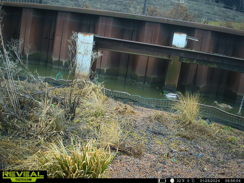

In [20]:
im = Image.open("/kaggle/working/_tests/Anas_platyrhynchos.JPG")
im.to_thumb(244,244)

Yes, ok - the ducks are in the background and maybe hard to see.

## A pretty prediction plot for 9 of the test images

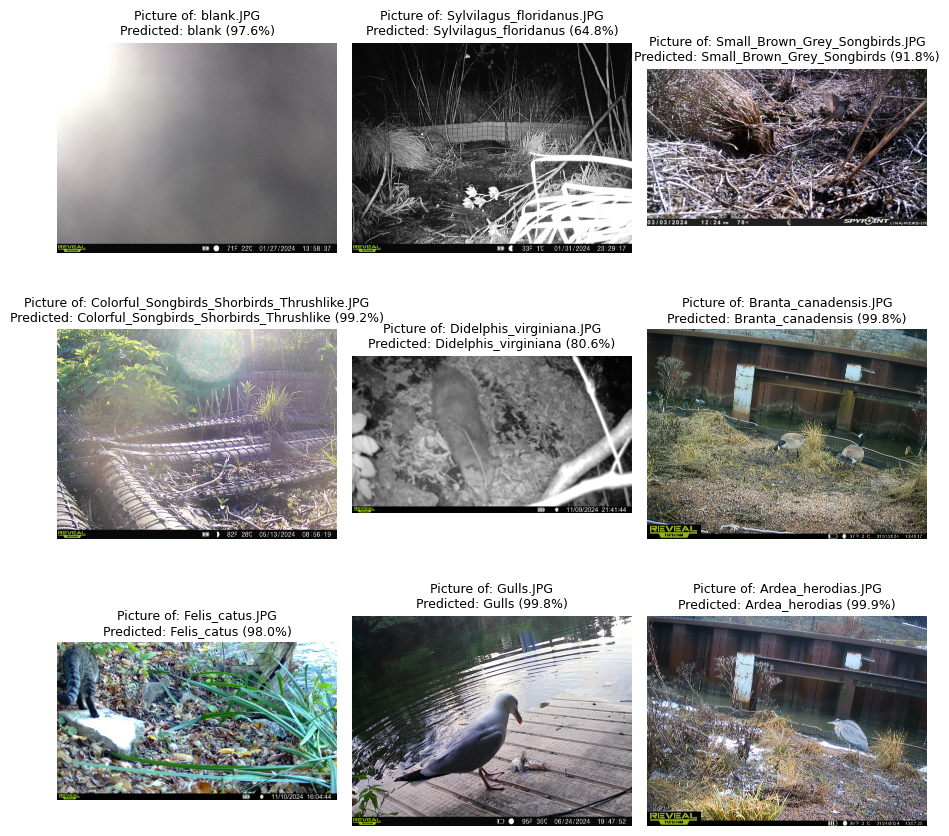

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()

for ax, img_file in zip(axes, test_files):
    img = PILImage.create(img_file)
    pred_class, pred_idx, pred_probs = learn.predict(img)

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Picture of: {img_file.name}\nPredicted: {pred_class} ({pred_probs[pred_idx]:.1%})", fontsize=9)

# Hide unused subplots if fewer than 9 images
for ax in axes[len(test_files):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Exporting the fine tuned model

In [22]:
# export the model for futher use
learn.export('/kaggle/working/2025-07-03-convnet_tiny_xmin2max42pe20-v11.pkl')